In [100]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import pathlib

sns.set_style("whitegrid")
sns.set_context("paper")
sns.set_palette("deep", color_codes=True)


In [101]:
result_files = {path.as_posix().split("/")[-1].split(".")[0]: {"path": path} for path in list(pathlib.Path("qaoa/qaoa_results_3").glob("*.npz"))}
result_files

{'5PTI_22_28_4_8_layers': {'path': PosixPath('qaoa/qaoa_results_3/5PTI_22_28_4_8_layers.npz')},
 '5PTI_22_28_4_12_layers': {'path': PosixPath('qaoa/qaoa_results_3/5PTI_22_28_4_12_layers.npz')},
 '5PTI_18_22_4_12_layers': {'path': PosixPath('qaoa/qaoa_results_3/5PTI_18_22_4_12_layers.npz')},
 '5PTI_18_22_4_1_layers': {'path': PosixPath('qaoa/qaoa_results_3/5PTI_18_22_4_1_layers.npz')},
 '5PTI_18_22_4_4_layers': {'path': PosixPath('qaoa/qaoa_results_3/5PTI_18_22_4_4_layers.npz')},
 '5PTI_22_28_4_2_layers': {'path': PosixPath('qaoa/qaoa_results_3/5PTI_22_28_4_2_layers.npz')},
 '5PTI_18_22_5_1_layers': {'path': PosixPath('qaoa/qaoa_results_3/5PTI_18_22_5_1_layers.npz')},
 '5PTI_22_28_4_1_layers': {'path': PosixPath('qaoa/qaoa_results_3/5PTI_22_28_4_1_layers.npz')},
 '5PTI_22_28_4_4_layers': {'path': PosixPath('qaoa/qaoa_results_3/5PTI_22_28_4_4_layers.npz')},
 '5PTI_18_22_4_2_layers': {'path': PosixPath('qaoa/qaoa_results_3/5PTI_18_22_4_2_layers.npz')},
 '5PTI_18_22_4_8_layers': {'path': P

In [102]:
data_keys = ["cost_history", "target_probs", "target_indices", "best_target_index", "conformation_map"]

for name, data in result_files.items():
    with open(data["path"], 'rb') as f:
        saved_results = np.load(f, allow_pickle=True)
        result_files[name]["data"] = {key: saved_results[key] for key in data_keys}

    result_files[name]["protein"] = name.split("_")[0]
    result_files[name]["start_residue"] = int(name.split("_")[1])
    result_files[name]["end_residue"] = int(name.split("_")[2])
    result_files[name]["rotamer_count"] = int(name.split("_")[3])
    result_files[name]["qaoa_layers"] = int(name.split("_")[4])

    result_files[name]["subsection"] = f"{result_files[name]['start_residue']}-{result_files[name]['end_residue']}"
    result_files[name]["subsection_length"] = result_files[name]["end_residue"] - result_files[name]["start_residue"] + 1

In [103]:
result_files

{'5PTI_22_28_4_8_layers': {'path': PosixPath('qaoa/qaoa_results_3/5PTI_22_28_4_8_layers.npz'),
  'data': {'cost_history': array([[-21.79895 , -21.795443, -21.799229, ..., -21.835983, -21.83601 ,
           -21.836031],
          [-21.508835, -21.50698 , -21.508553, ..., -21.510225, -21.51023 ,
           -21.510235],
          [-21.508833, -21.497353, -21.508078, ..., -21.770592, -21.772045,
           -21.773483],
          ...,
          [-21.552189, -21.549726, -21.552666, ..., -21.700994, -21.701063,
           -21.701118],
          [-21.508833, -21.502392, -21.507399, ..., -21.784811, -21.785938,
           -21.787037],
          [-21.797321, -21.794855, -21.798887, ..., -21.836435, -21.836462,
           -21.836493]], shape=(30, 150), dtype=float32),
   'target_probs': array([[7.45149143e-03, 7.02294847e-03, 7.70822726e-03, 1.07697332e-02,
           2.69392692e-02, 2.31143627e-02, 2.83292029e-02, 3.77013534e-02,
           2.57623270e-02, 7.14490516e-03, 6.73399400e-03, 1.03266

In [104]:
# result_files["5PTI_22_28_5_8_layers"]["data"]

In [105]:
target_probs_records = []

for name, data in result_files.items():
    target_probs = result_files[name]["data"]['target_probs']

    # Handle both 1D and 2D arrays
    if target_probs.ndim == 1:
        probs = target_probs
    else:
        # If 2D, you may need to flatten or iterate - adjust based on your data structure
        probs = target_probs.flatten()

    # Create a record for each probability value
    for i, prob in enumerate(probs):
        record = {
            'protein': result_files[name]['protein'],
            'subsection': result_files[name]['subsection'],
            'subsection_length': result_files[name]['subsection_length'],
            'rotamer_count': result_files[name]['rotamer_count'],
            'qaoa_layers': result_files[name]['qaoa_layers'],
            'seed': i,
            'target_prob': prob
        }
        target_probs_records.append(record)

# Create dataframe from records
target_probs_df = pd.DataFrame(target_probs_records)
target_probs_df.head()

,protein,subsection,subsection_length,rotamer_count,qaoa_layers,seed,target_prob
0,5PTI,22-28,7,4,8,0,0.007451
1,5PTI,22-28,7,4,8,1,0.007023
2,5PTI,22-28,7,4,8,2,0.007708
3,5PTI,22-28,7,4,8,3,0.010770
4,5PTI,22-28,7,4,8,4,0.026939


In [106]:
target_probs_df

,protein,subsection,subsection_length,rotamer_count,qaoa_layers,seed,target_prob
0,5PTI,22-28,7,4,8,0,0.007451
1,5PTI,22-28,7,4,8,1,0.007023
2,5PTI,22-28,7,4,8,2,0.007708
3,5PTI,22-28,7,4,8,3,0.010770
4,5PTI,22-28,7,4,8,4,0.026939
...,...,...,...,...,...,...,...
3115,5PTI,18-22,5,4,8,115,0.024225
3116,5PTI,18-22,5,4,8,116,0.497038
3117,5PTI,18-22,5,4,8,117,0.045383
3118,5PTI,18-22,5,4,8,118,0.056675


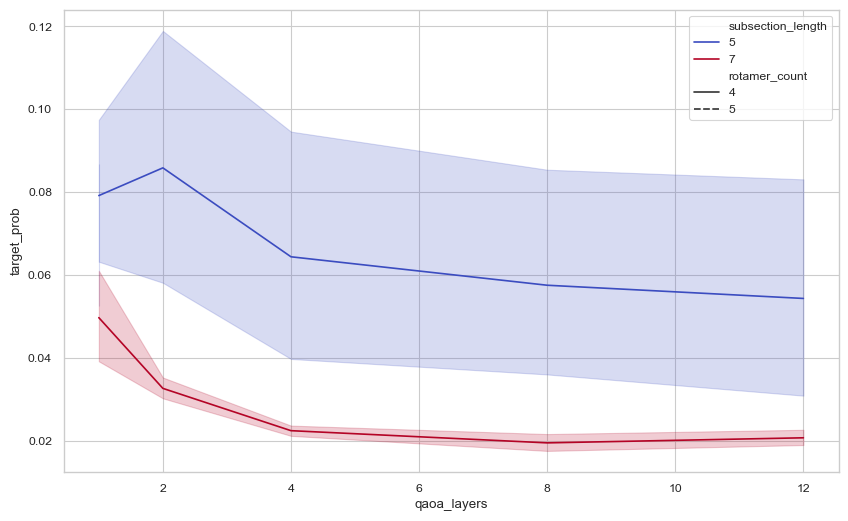

In [107]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=target_probs_df,
             x="qaoa_layers", y="target_prob",
             hue='subsection_length', style='rotamer_count',
             markers=False,
             palette=sns.color_palette('coolwarm', as_cmap = True),
             ax=ax)
plt.show()